# Airline Passengers - preparation des donnees

Chargement de la serie, normalisation 0-1, split temporel 67/33 et fenetre glissante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import keras

2026-07-17 10:58:28.638694: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-17 10:58:29.303225: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(URL)['Passengers'].values.astype('float32').reshape(-1, 1)
print('shape:', data.shape, 'min:', data.min(), 'max:', data.max())

shape: (144, 1) min: 104.0 max: 622.0


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
print('apres MinMax -> min:', data_scaled.min(), 'max:', data_scaled.max())

apres MinMax -> min: 0.0 max: 1.0


In [4]:
train_size = int(len(data_scaled) * 0.67)
train, test = data_scaled[:train_size], data_scaled[train_size:]
print('train:', train.shape, 'test:', test.shape)

train: (96, 1) test: (48, 1)


In [5]:
def create_dataset(dataset, window_size=12):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    X = np.array(X)
    return X.reshape(X.shape[0], window_size, 1), np.array(y)

In [6]:
WINDOW_SIZE = 12
X_train, y_train = create_dataset(train, WINDOW_SIZE)
X_test, y_test = create_dataset(test, WINDOW_SIZE)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

X_train: (84, 12, 1) y_train: (84,)
X_test : (36, 12, 1) y_test : (36,)


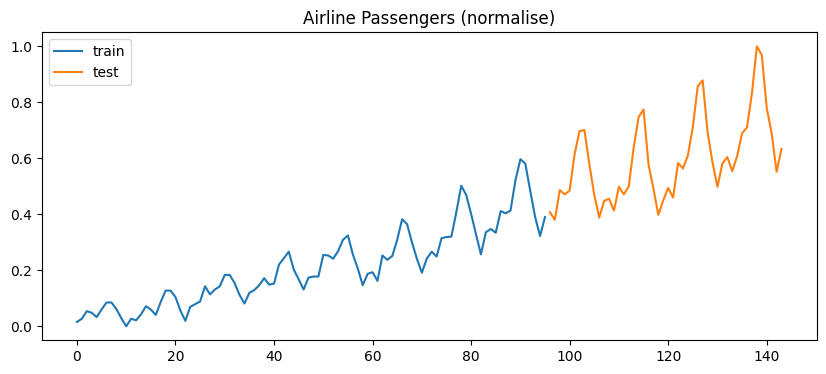

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(range(train_size), train[:, 0], label='train')
plt.plot(range(train_size, len(data_scaled)), test[:, 0], label='test')
plt.legend()
plt.title('Airline Passengers (normalise)')
plt.show()